[![Open In Colab](https://colab.research.google.com/assets/colab-badge.svg)](https://colab.research.google.com/github/arvidl/BMED365-2026/blob/main/Lab5-Comp-Mod/notebooks/03-cardiovascular-flow.ipynb)

# 03 — Cardiovascular Flow Dynamics

**BMED365 – Computational Medicine (Lab 5)**

_Arvid Lundervold w/ Claude (Anthropic) & Grok (xAI) — 2025-02-23_<br>
_Updated: 2026-02-19_  (Cursor 2.5.17 with Claude Opus 4.6) <br>
_Updated: 2026-02-20_  (Cursor 2.5.20 with Claude Opus 4.6) - saved notebook to .pdf<br>
_Updated: 2026-02-28_  (Ubuntu 24.04, Cursor 2.5.26 with Claude Opus 4.6) - Testing

---

## 1. Motivation & Learning Objectives

### Why study cardiovascular flow dynamics?

The cardiovascular system is one of the most critical organ systems in the human body. The heart pumps approximately **5 liters of blood per minute** through a vast network of blood vessels spanning over **100,000 km** in total length. Understanding how blood flows through this network — how pressure waves propagate, how vessel compliance affects flow, and how pathological changes disrupt normal hemodynamics — is fundamental to modern medicine.

**Cardiovascular disease (CVD) remains the leading cause of death worldwide**, accounting for approximately 17.9 million deaths annually (WHO). Mathematical modeling of cardiovascular flow provides insight into disease mechanisms, guides surgical planning, and enables the design of medical devices such as artificial heart valves and stents.

From a computational perspective, cardiovascular flow modeling beautifully illustrates how the **same physical system** can be represented at multiple levels of abstraction — from simple lumped-parameter circuit analogies to full three-dimensional fluid–structure interaction simulations — each offering a different balance between simplicity, insight, and predictive power.

### What you will learn

In this notebook you will:

1. **Understand** the biological basis of cardiovascular flow — how the heart generates pressure waves and how blood flows through the vascular tree
2. **Appreciate** the historical context — from William Harvey's discovery of blood circulation (1628) to modern computational fluid dynamics
3. **Master** the hierarchy of cardiovascular flow models — from simple lumped-parameter (Windkessel) models to advanced PDE-based models
4. **Implement** a lumped-parameter cardiovascular model in Python and simulate pressure and flow dynamics
5. **Visualize** and interpret pressure waveforms, flow rates, and their relationship to the ECG
6. **Explore** clinical implications — from hypertension to aortic stenosis to aneurysm mechanics

## 2. Historical Context: From Harvey to Computational Hemodynamics

### The quest to understand blood flow

The understanding of blood circulation has a rich history spanning nearly two millennia, from Galen's ancient theories to modern patient-specific computational simulations:

| Year | Milestone | Scientists |
|------|-----------|------------|
| ~170 AD | Galenic model: blood produced in liver, consumed by tissues | **Galen** of Pergamon |
| 1242 | First description of pulmonary circulation | Ibn al-**Nafis** |
| 1628 | *De Motu Cordis* — experimental proof of blood circulation | William **Harvey** |
| 1733 | First blood pressure measurement (in a horse!) | Stephen **Hales** |
| 1828 | Navier-Stokes equations for viscous fluid flow | **Navier** & **Stokes** |
| 1840 | Poiseuille's law for flow in cylindrical tubes | Jean Léonard Marie **Poiseuille** |
| 1878 | Pulse wave velocity measurements in arteries | Étienne-Jules **Marey** |
| 1899 | **Windkessel** (air-chamber) model of arterial compliance | Otto **Frank** |
| 1955 | Theory of pulsatile flow in elastic tubes | John R. **Womersley** |
| 1960s | First computational models of arterial hemodynamics | several groups |
| 1990s | Patient-specific CFD from medical imaging (CT/MRI) | C.A. Taylor and others |
| 2000s– | Coupled multiscale models; 4D Flow MRI validation | multiple groups |

### William Harvey and the proof of circulation

Before Harvey, the prevailing view (from **Galen**, ~170 AD) was that blood was continuously produced in the liver, distributed through veins, consumed by tissues, and that arteries carried "vital spirits" mixed with air. This model had dominated Western medicine for nearly **1,500 years**.

**William Harvey** (1578–1657) demonstrated through careful experiments and quantitative reasoning that:

1. The heart acts as a **pump**, propelling blood through arteries
2. Blood circulates in a **closed loop** — arterial blood returns to the heart through veins
3. The **volume argument**: Harvey calculated that the heart pumps far more blood per hour than the body's total blood volume, proving the same blood must recirculate
4. **Valves** in veins ensure one-way flow back to the heart

> *"I began to think whether there might not be a motion, as it were, in a circle."*
> — William Harvey, *Exercitatio Anatomica de Motu Cordis et Sanguinis in Animalibus* (1628)

Harvey's work is one of the great achievements in the history of physiology and set the stage for all subsequent understanding of cardiovascular function.

### Otto Frank and the Windkessel model (1899)

The German physiologist **Otto Frank** (1865–1944) developed one of the first mathematical models of arterial blood flow. He observed that large arteries are **elastic** — they expand during systole (when the heart ejects blood) and recoil during diastole (when the heart relaxes). This behavior is analogous to the **Windkessel** (German for "air chamber") used in fire engines of the era — a closed air chamber that smooths pulsatile pump output into a more continuous stream.

Frank's insight that the **elasticity of large arteries** plays a crucial role in hemodynamics laid the foundation for all subsequent cardiovascular flow modeling. The Windkessel model remains widely used today as a simple but effective representation of arterial hemodynamics.

In [1]:
# --- Colab setup ---
import sys
if 'google.colab' in sys.modules:
    pass  # all dependencies are standard; no additional setup needed

In [4]:
# --- Colab setup ---
import sys
if 'google.colab' in sys.modules:
    pass  # all dependencies are standard; no additional setup needed

In [6]:
from IPython.display import display, HTML

display(HTML('''
<div style="display: flex; justify-content: center; gap: 40px; margin: 20px 0; flex-wrap: wrap; align-items: flex-start;">
<figure style="text-align:center; max-width:280px;">
<img src="assets/william_harvey.jpg"
     alt="William Harvey (1578-1657)" width="260" />
<figcaption style="font-size:0.85em; color:#555; margin-top:6px;">
<b>William Harvey</b> (1578-1657). Proved that blood circulates
in a closed loop, with the heart as a pump.<br/>
<i>Source: Wikimedia Commons (public domain).</i>
</figcaption>
</figure>

<figure style="text-align:center; max-width:280px;">
<img src="assets/windkessel_model.svg"
     alt="2-Element Windkessel model" width="260"
     style="background:#fff; padding:10px; border:1px solid #ddd; border-radius:4px;" />
<figcaption style="font-size:0.85em; color:#555; margin-top:6px;">
<b>Otto Frank</b> (1865-1944) developed the <b>Windkessel</b> (air-chamber)
model of arterial compliance (1899), shown here as an electrical analog.<br/>
<i>Diagram: Wikimedia Commons (CC BY-SA 4.0, K. Rachid).</i>
</figcaption>
</figure>
</div>
'''))

## 3. The Cardiovascular System: Biological Background

### The heart as a pump

The heart is a four-chambered muscular pump that generates the pressure needed to drive blood through the circulatory system:

- **Right atrium** → receives deoxygenated blood from the body via the vena cava
- **Right ventricle** → pumps blood to the lungs via the pulmonary artery
- **Left atrium** → receives oxygenated blood from the lungs via the pulmonary veins
- **Left ventricle** → pumps oxygenated blood to the entire body via the aorta

The left ventricle generates the highest pressures (~120/80 mmHg systolic/diastolic in a healthy adult) because it must push blood through the entire **systemic circulation**.

### The vascular tree

The vascular system can be conceptualized as a branching tree with dramatically varying properties:

| Vessel type | Diameter | Function | Typical pressure |
|-------------|----------|----------|------------------|
| **Aorta** | ~25 mm | Windkessel effect; stores elastic energy | 120/80 mmHg |
| **Large arteries** | 4–25 mm | Conduct blood to organs; pulse wave propagation | 110/75 mmHg |
| **Arterioles** | 0.01–4 mm | **Major site of resistance regulation** | 40–80 mmHg |
| **Capillaries** | 5–10 µm | Gas and nutrient exchange | 15–35 mmHg |
| **Venules / Veins** | 0.01–30 mm | Return blood to heart; capacitance vessels | 5–15 mmHg |
| **Vena cava** | ~30 mm | Final return path to right atrium | 2–5 mmHg |

### The cardiac cycle

Each heartbeat (~0.8 s at 75 bpm) consists of two main phases:

1. **Systole** (~0.3 s): The ventricles **contract**, ejecting blood into the arteries
   - Pressure in the left ventricle rises from ~5 to ~120 mmHg
   - The aortic valve opens when LV pressure exceeds aortic pressure
   - Blood is ejected at peak velocities of ~1 m/s into the aorta

2. **Diastole** (~0.5 s): The ventricles **relax** and fill with blood
   - Aortic valve closes → creates the **dicrotic notch** in the aortic pressure waveform
   - Elastic recoil of arterial walls maintains pressure during diastole
   - The heart fills passively, then via atrial contraction (the "atrial kick")

### Key hemodynamic quantities

- **Cardiac output** (CO): Volume pumped per minute. CO = Heart Rate × Stroke Volume ≈ 75 bpm × 70 ml ≈ 5.25 L/min
- **Blood pressure** (BP): Force per unit area on vessel walls (measured in mmHg). Normal: 120/80 mmHg
- **Peripheral resistance** (TPR): Opposition to flow, mainly in arterioles. Mean BP ≈ CO × TPR
- **Compliance** ($C$): Ability of vessels to expand: $C = \Delta V / \Delta P$ (ml/mmHg)
- **Pulse wave velocity** (PWV): Speed of pressure waves along arteries (4–10 m/s in humans; increases with arterial stiffness)

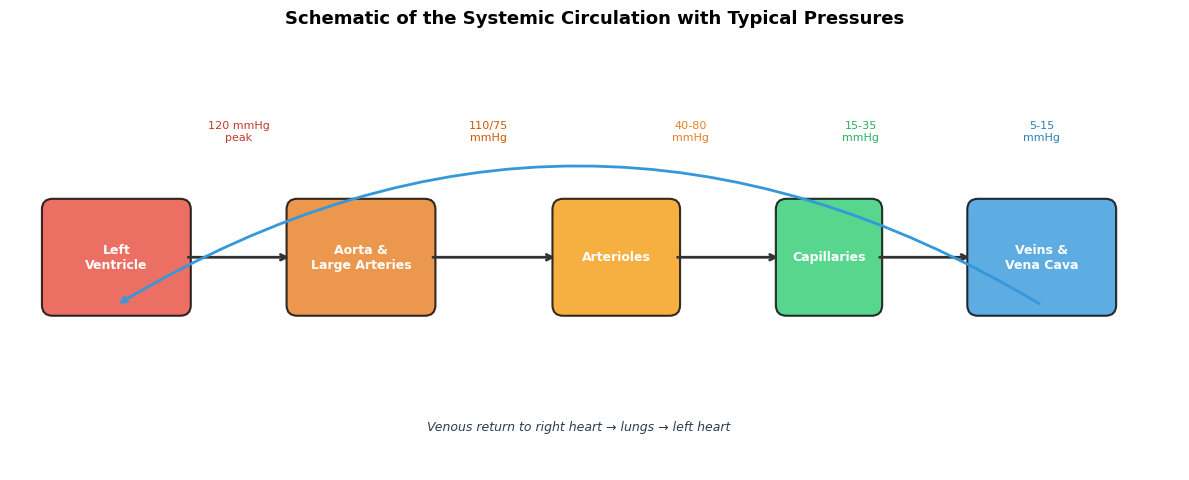

In [7]:
import matplotlib.pyplot as plt
import matplotlib.patches as mpatches
from matplotlib.patches import FancyBboxPatch, FancyArrowPatch
import numpy as np
np.random.seed(42)

fig, ax = plt.subplots(1, 1, figsize=(12, 5))
ax.set_xlim(-0.5, 10.5)
ax.set_ylim(-1.5, 2.5)
ax.set_aspect('equal')
ax.axis('off')

# Define compartments
compartments = [
    (0.5, 0.5, 'Left\nVentricle', '#e74c3c', 1.2),
    (2.8, 0.5, 'Aorta &\nLarge Arteries', '#e67e22', 1.2),
    (5.2, 0.5, 'Arterioles', '#f39c12', 1.0),
    (7.2, 0.5, 'Capillaries', '#2ecc71', 0.8),
    (9.2, 0.5, 'Veins &\nVena Cava', '#3498db', 1.2),
]

for x, y, label, color, w in compartments:
    box = FancyBboxPatch((x - w/2, y - 0.45), w, 0.9,
                          boxstyle="round,pad=0.1", facecolor=color,
                          edgecolor='black', linewidth=1.5, alpha=0.8)
    ax.add_patch(box)
    ax.text(x, y, label, ha='center', va='center', fontsize=9, fontweight='bold', color='white')

# Arrows between compartments
for i in range(len(compartments) - 1):
    x1 = compartments[i][0] + compartments[i][4]/2 + 0.05
    x2 = compartments[i+1][0] - compartments[i+1][4]/2 - 0.05
    ax.annotate('', xy=(x2, 0.5), xytext=(x1, 0.5),
                arrowprops=dict(arrowstyle='->', color='#333', lw=2))

# Return arrow (veins back to heart)
ax.annotate('', xy=(0.5, 0.05), xytext=(9.2, 0.05),
            arrowprops=dict(arrowstyle='->', color='#3498db', lw=2,
                           connectionstyle='arc3,rad=0.3'))
ax.text(4.85, -1.1, 'Venous return to right heart \u2192 lungs \u2192 left heart',
        ha='center', va='center', fontsize=9, fontstyle='italic', color='#2c3e50')

# Pressure labels
ax.text(1.65, 1.6, '120 mmHg\npeak', ha='center', fontsize=8, color='#c0392b')
ax.text(4.0, 1.6, '110/75\nmmHg', ha='center', fontsize=8, color='#d35400')
ax.text(5.9, 1.6, '40-80\nmmHg', ha='center', fontsize=8, color='#e67e22')
ax.text(7.5, 1.6, '15-35\nmmHg', ha='center', fontsize=8, color='#27ae60')
ax.text(9.2, 1.6, '5-15\nmmHg', ha='center', fontsize=8, color='#2980b9')

ax.set_title('Schematic of the Systemic Circulation with Typical Pressures',
             fontsize=13, fontweight='bold', pad=15)
plt.tight_layout()
plt.show()

## 4. Scientific and Clinical Implications

Understanding cardiovascular flow dynamics through mathematical modeling has had far-reaching consequences in both basic science and clinical medicine:

### Cardiovascular Disease & Diagnostics
- **Hypertension** affects ~1.3 billion people worldwide. Lumped-parameter models help explain how increased peripheral resistance and reduced arterial compliance lead to elevated blood pressure
- **Atherosclerosis** — plaque buildup in arteries is associated with regions of **low and oscillatory wall shear stress**, which can be predicted by computational flow models
- **Aortic aneurysms** — weakened vessel walls lead to abnormal dilation; CFD simulations predict rupture risk based on wall stress distributions
- **Pulse wave velocity** (PWV) is a clinically validated biomarker of arterial stiffness and cardiovascular risk — directly related to vessel compliance in Windkessel models

### Surgical Planning & Medical Devices
- **Coronary artery bypass grafting** (CABG): Flow models help plan optimal graft placement and predict post-surgical hemodynamics
- **Stent design**: CFD simulations predict how stents affect local flow patterns and wall shear stress, informing device optimization
- **Artificial heart valves**: Prosthetic valve design relies heavily on flow modeling to minimize thrombosis and hemolysis
- **Ventricular assist devices** (VADs): Hemodynamic models guide device sizing, control algorithms, and patient selection

### Advanced Diagnostics & Imaging
- **Fractional flow reserve** (FFR): Pressure measurements combined with flow models assess the functional significance of coronary artery stenosis — increasingly done *non-invasively* via CT-derived FFR (FFR_CT)
- **4D Flow MRI**: Combines velocity-encoded MRI with computational models for comprehensive, patient-specific hemodynamic assessment
- **Echocardiography** + flow models → non-invasive estimation of cardiac function, valve severity, and pulmonary pressures

### Drug Development & Pharmacology
- Understanding how blood flow distributes drugs through the body (pharmacokinetics)
- Modeling how vasoactive drugs (e.g., nitroprusside, norepinephrine) alter hemodynamics by changing resistance and compliance parameters

> *Mathematical modeling of cardiovascular flow has evolved from simple analogies to patient-specific computational simulations that directly inform clinical decision-making.*

### Check Your Understanding: Cardiovascular Basics

**Q1.** Why does blood pressure *decrease* as it flows from large arteries to capillaries to veins?

<details>
<summary>Click to reveal answer</summary>

Blood pressure decreases along the vascular tree due to **energy loss from viscous friction** as blood flows through the vessels. The greatest pressure drop occurs across the **arterioles**, which are the main site of vascular resistance. This is analogous to voltage drop across a resistor in an electrical circuit — the higher the resistance, the greater the pressure (voltage) drop for a given flow (current).

Mathematically: $\Delta P = Q \times R$ (Ohm's law analog). Since arterioles have the highest total resistance, they produce the largest pressure drop.

</details>

---

**Q2.** What is the role of arterial **compliance** (elasticity) in the cardiovascular system? What would happen if arteries were rigid tubes?

<details>
<summary>Click to reveal answer</summary>

Arterial compliance serves a crucial **Windkessel** (buffering) function:

1. During **systole**, elastic arteries expand to store a portion of the ejected blood volume
2. During **diastole**, the elastic walls recoil, pushing stored blood forward and maintaining flow

If arteries were rigid, the **systolic pressure would be much higher** (dangerous for vessel walls and organs), **diastolic pressure would drop to near zero** (no perfusion between heartbeats), and flow would be highly pulsatile. This is essentially what happens with **arterial stiffening in aging** — pulse pressure (systolic minus diastolic) increases, which is a major cardiovascular risk factor.

The compliance is quantified as $C = \Delta V / \Delta P$. Healthy large arteries: $C \approx 1$–$2$ ml/mmHg.

</details>

---

**Q3.** If cardiac output is 5 L/min and mean arterial pressure is 93 mmHg (with venous pressure ≈ 0), what is the total peripheral resistance?

<details>
<summary>Click to reveal answer</summary>

Using the hemodynamic analog of Ohm's law:

$$\text{TPR} = \frac{\text{MAP} - \text{CVP}}{\text{CO}} = \frac{93 - 0}{5000 \text{ ml/min}} = 0.0186 \text{ mmHg\cdot min/ml}$$

Converting to more common units (mmHg·s/ml): multiply by 60 → TPR ≈ **1.12 mmHg·s/ml** (or ~1.12 PRU, peripheral resistance units).

This is a useful "sanity check" for computational models — if your simulated total resistance is far from this value, something is likely wrong.

</details>

## 5. Modeling Cardiovascular Flow: From Windkessel to Navier-Stokes

### The hierarchy of flow models

Cardiovascular flow can be modeled at different levels of complexity. Each level offers a different trade-off between **computational cost** and **physical fidelity**:

#### Level 0: Lumped-Parameter (0D) Models — The Windkessel Family

- Treat the vasculature as **discrete compartments** connected by resistances
- Use the **electrical circuit analogy** (pressure ↔ voltage, flow ↔ current, compliance ↔ capacitance)
- Capture **global hemodynamics**: pressure, flow rate, and volume as functions of time
- **Cannot** resolve spatial flow patterns within vessels
- Computationally **very fast** — system of ODEs
- *Example*: The 2-, 3-, and 4-element Windkessel models

#### Level 1: One-Dimensional (1D) Models

- Resolve flow along the **length** of vessels (one spatial dimension)
- Use **cross-sectionally averaged** equations (area, flow rate, pressure as functions of position and time)
- Capture **pulse wave propagation**, wave reflections at bifurcations, and pressure/flow distribution in arterial networks
- Moderate computational cost — system of **hyperbolic PDEs**
- *Example*: 1D arterial network models (e.g., Olufsen et al., Sherwin et al.)

#### Level 2: Three-Dimensional (3D) CFD Models

- Solve the full **Navier-Stokes equations** in realistic 3D vessel geometries
- Resolve detailed **velocity fields**, wall shear stress, recirculation zones
- Can use **patient-specific geometry** from medical imaging (CT angiography, MRI)
- **High computational cost** — often requires HPC resources
- Essential for studying local flow phenomena near stenoses, bifurcations, and valves
- *Example*: Patient-specific aortic flow simulations, virtual FFR

### Multiscale coupling

Modern approaches often **couple** models at different levels. For example, a 3D model of the aorta may be coupled with 1D models of downstream arteries and 0D (Windkessel) models as outlet boundary conditions. This provides both local detail where needed and global context.

### The Windkessel models in detail

The Windkessel family of models progresses in complexity:

| Model | Elements | Captures | Misses |
|-------|----------|----------|--------|
| **2-element** (RC) | Resistance R, Compliance C | Diastolic pressure decay | High-frequency impedance |
| **3-element** (RCR) | Adds characteristic impedance $Z_0$ | Aortic input impedance at high frequencies | Inertial effects |
| **4-element** (RLCR) | Adds inertance $L$ | Blood inertia; better high-frequency behavior | Spatial wave propagation |

#### Two-Element Windkessel (Frank, 1899)

The simplest model — a single peripheral resistance $R$ and arterial compliance $C$:

$$C \frac{dP}{dt} = Q_{\text{in}}(t) - \frac{P - P_{\text{venous}}}{R}$$

#### Three-Element Windkessel

Adds characteristic impedance $Z_0$ (representing the impedance of the proximal aorta) in series with the RC element:

$$P_{\text{aorta}} = Z_0 \, Q_{\text{in}} + P_C \quad ; \quad C \frac{dP_C}{dt} = Q_{\text{in}} - \frac{P_C}{R}$$

### The Navier-Stokes equations for blood flow

At the most fundamental level, blood flow is governed by **conservation of momentum** (Navier-Stokes) and **conservation of mass** (continuity):

$$\rho \left(\frac{\partial \mathbf{u}}{\partial t} + \mathbf{u} \cdot \nabla \mathbf{u}\right) = -\nabla p + \mu \nabla^2 \mathbf{u} + \mathbf{f}$$

$$\nabla \cdot \mathbf{u} = 0$$

where $\rho \approx 1060$ kg/m³ (blood density), $\mathbf{u}$ is the velocity field, $p$ is pressure, $\mu \approx 3.5 \times 10^{-3}$ Pa·s (dynamic viscosity), and $\mathbf{f}$ represents body forces.

For blood flow in elastic vessels, these equations must be coupled with models of **wall mechanics** — a challenging fluid–structure interaction (FSI) problem.

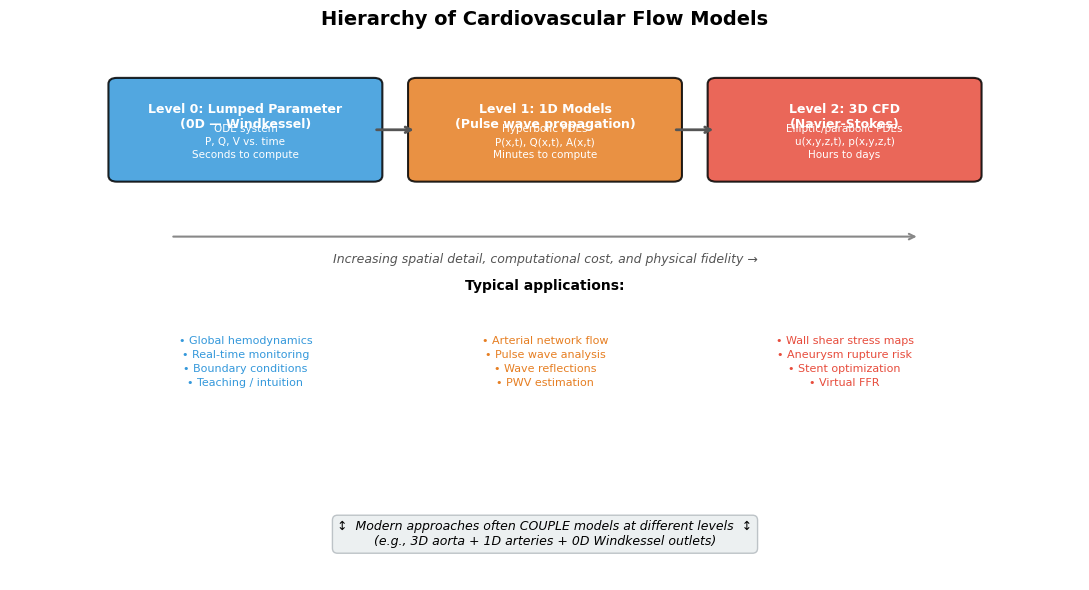

In [8]:
import matplotlib.pyplot as plt
import matplotlib.patches as mpatches

fig, ax = plt.subplots(figsize=(11, 6))
ax.set_xlim(0, 10)
ax.set_ylim(0, 7)
ax.axis('off')

# Three model levels as colored boxes
levels = [
    (1.0, 5.3, 2.4, 1.2, '#3498db', 'Level 0: Lumped Parameter\n(0D \u2014 Windkessel)',
     'ODE system\nP, Q, V vs. time\nSeconds to compute'),
    (3.8, 5.3, 2.4, 1.2, '#e67e22', 'Level 1: 1D Models\n(Pulse wave propagation)',
     'Hyperbolic PDEs\nP(x,t), Q(x,t), A(x,t)\nMinutes to compute'),
    (6.6, 5.3, 2.4, 1.2, '#e74c3c', 'Level 2: 3D CFD\n(Navier-Stokes)',
     'Elliptic/parabolic PDEs\nu(x,y,z,t), p(x,y,z,t)\nHours to days'),
]

for x, y, w, h, color, title, desc in levels:
    rect = mpatches.FancyBboxPatch((x, y), w, h, boxstyle="round,pad=0.08",
                                    facecolor=color, alpha=0.85, edgecolor='black', lw=1.5)
    ax.add_patch(rect)
    ax.text(x + w/2, y + h - 0.25, title, ha='center', va='top',
            fontsize=9, fontweight='bold', color='white')
    ax.text(x + w/2, y + 0.2, desc, ha='center', va='bottom',
            fontsize=7.5, color='white', linespacing=1.4)

# Arrows showing increasing complexity
for i in range(2):
    x1 = levels[i][0] + levels[i][2]
    x2 = levels[i+1][0]
    ymid = levels[0][1] + levels[0][3]/2
    ax.annotate('', xy=(x2, ymid), xytext=(x1, ymid),
                arrowprops=dict(arrowstyle='->', lw=2, color='#555'))

# Labels for the complexity axis
ax.annotate('', xy=(8.5, 4.5), xytext=(1.5, 4.5),
            arrowprops=dict(arrowstyle='->', lw=1.5, color='#888'))
ax.text(5.0, 4.15, 'Increasing spatial detail, computational cost, and physical fidelity \u2192',
        ha='center', fontsize=9, fontstyle='italic', color='#555')

# Example use cases
use_cases = [
    (2.2, 3.2, '\u2022 Global hemodynamics\n\u2022 Real-time monitoring\n\u2022 Boundary conditions\n\u2022 Teaching / intuition',
     '#3498db'),
    (5.0, 3.2, '\u2022 Arterial network flow\n\u2022 Pulse wave analysis\n\u2022 Wave reflections\n\u2022 PWV estimation',
     '#e67e22'),
    (7.8, 3.2, '\u2022 Wall shear stress maps\n\u2022 Aneurysm rupture risk\n\u2022 Stent optimization\n\u2022 Virtual FFR',
     '#e74c3c'),
]

ax.text(5.0, 3.8, 'Typical applications:', ha='center', fontsize=10, fontweight='bold')
for x, y, text, color in use_cases:
    ax.text(x, y, text, ha='center', va='top', fontsize=8, color=color, linespacing=1.5)

# Coupling note
ax.text(5.0, 0.6, '\u2195  Modern approaches often COUPLE models at different levels  \u2195\n'
        '(e.g., 3D aorta + 1D arteries + 0D Windkessel outlets)',
        ha='center', va='center', fontsize=9, fontstyle='italic',
        bbox=dict(boxstyle='round,pad=0.4', facecolor='#ecf0f1', edgecolor='#bdc3c7'))

ax.set_title('Hierarchy of Cardiovascular Flow Models', fontsize=14, fontweight='bold', pad=15)
plt.tight_layout()
plt.show()

## 6. The Lumped-Parameter (Windkessel) Model: Conceptual Framework

### The vessel wall as an electrical circuit

Just as Hodgkin and Huxley modeled the neural membrane as an electrical circuit (see Notebook 01), cardiovascular physiologists have long modeled the vascular system using an **electrical circuit analogy**:

| Cardiovascular quantity | Electrical analog | Symbol | Unit |
|------------------------|-------------------|--------|------|
| **Pressure** (P) | Voltage (V) | $P$ | mmHg |
| **Flow rate** (Q) | Current (I) | $Q$ | ml/s |
| **Vascular resistance** | Resistance (R) | $R$ | mmHg·s/ml |
| **Vessel compliance** | Capacitance (C) | $C$ | ml/mmHg |
| **Blood inertance** | Inductance (L) | $L$ | mmHg·s²/ml |
| **Blood volume** | Charge (q) | $V$ | ml |

This analogy is powerful because it allows us to use well-understood circuit theory to analyze hemodynamics!

### Our model: Multi-compartment lumped-parameter network

In this notebook, we model the cardiovascular system as a **series of connected compartments**, each representing a major section of the vasculature:

1. **Heart (P₀)**: A time-varying pressure source (the left ventricle)
2. **Compartment 1 (P₁)**: Represents the aorta and large arteries — with compliance $C_1$
3. **Compartment 2 (P₂)**: Represents smaller arteries and arterioles — with compliance $C_2$
4. **Venous system (P₃)**: Constant venous pressure (the "ground" of our circuit)

Adjacent compartments are connected by **resistances** ($R_0, R_1, R_2$) representing the viscous resistance to flow.

### The electrical circuit analogy diagram

The heart acts as a **time-varying voltage source** (pressure generator), and each vascular compartment is a node with a capacitor (compliance) to ground. Resistors connect the nodes. See the programmatic diagram below for a clear visualization of this circuit.

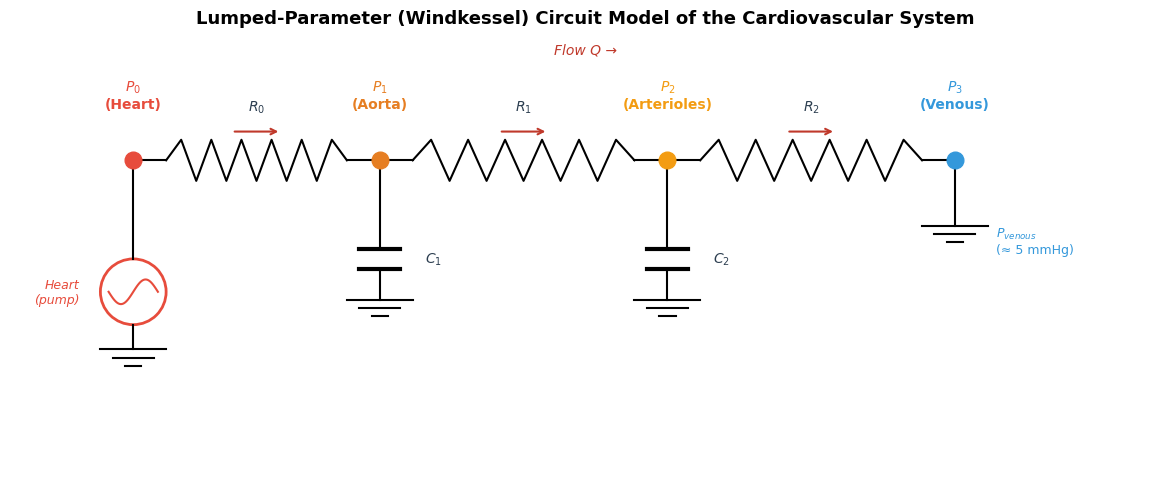

In [9]:
import matplotlib.pyplot as plt
import matplotlib.patches as mpatches
import numpy as np

fig, ax = plt.subplots(figsize=(12, 5))
ax.set_xlim(-1, 13)
ax.set_ylim(-2.5, 3)
ax.set_aspect('equal')
ax.axis('off')

# Node positions along top wire
nodes_x = [0.5, 3.5, 7.0, 10.5]
nodes_y = [1.5, 1.5, 1.5, 1.5]
node_labels = ['$P_0$\n(Heart)', '$P_1$\n(Aorta)', '$P_2$\n(Arterioles)', '$P_3$\n(Venous)']
node_colors = ['#e74c3c', '#e67e22', '#f39c12', '#3498db']

# Draw nodes
for x, y, label, color in zip(nodes_x, nodes_y, node_labels, node_colors):
    ax.plot(x, y, 'o', markersize=12, color=color, zorder=5)
    ax.text(x, y + 0.6, label, ha='center', va='bottom', fontsize=10, fontweight='bold', color=color)

# Draw resistors (zigzag lines between nodes)
def draw_resistor(ax, x1, x2, y, label):
    mid = (x1 + x2) / 2
    pad = 0.4
    ax.plot([x1, x1 + pad], [y, y], 'k-', lw=1.5)
    ax.plot([x2 - pad, x2], [y, y], 'k-', lw=1.5)
    n_teeth = 6
    zx = np.linspace(x1 + pad, x2 - pad, n_teeth * 2 + 1)
    zy = np.zeros_like(zx) + y
    zy[1::2] = y + 0.25
    zy[2::2] = y - 0.25
    zy[0] = y; zy[-1] = y
    ax.plot(zx, zy, 'k-', lw=1.5)
    ax.text(mid, y + 0.55, label, ha='center', va='bottom', fontsize=10,
            fontweight='bold', color='#2c3e50')

draw_resistor(ax, nodes_x[0], nodes_x[1], nodes_y[0], '$R_0$')
draw_resistor(ax, nodes_x[1], nodes_x[2], nodes_y[1], '$R_1$')
draw_resistor(ax, nodes_x[2], nodes_x[3], nodes_y[2], '$R_2$')

# Draw capacitors (compliance) hanging from P1 and P2
def draw_capacitor(ax, x, y_top, label):
    y_cap = y_top - 1.2
    gap = 0.12
    plate_w = 0.5
    ax.plot([x, x], [y_top, y_cap + gap], 'k-', lw=1.5)
    ax.plot([x - plate_w/2, x + plate_w/2], [y_cap + gap, y_cap + gap], 'k-', lw=3)
    ax.plot([x - plate_w/2, x + plate_w/2], [y_cap - gap, y_cap - gap], 'k-', lw=3)
    ax.plot([x, x], [y_cap - gap, y_cap - 0.5], 'k-', lw=1.5)
    gnd_y = y_cap - 0.5
    for i, w in enumerate([0.4, 0.25, 0.1]):
        ax.plot([x - w, x + w], [gnd_y - i*0.1, gnd_y - i*0.1], 'k-', lw=1.5)
    ax.text(x + 0.55, y_cap, label, ha='left', va='center', fontsize=10,
            fontweight='bold', color='#2c3e50')

draw_capacitor(ax, nodes_x[1], nodes_y[1], '$C_1$')
draw_capacitor(ax, nodes_x[2], nodes_y[2], '$C_2$')

# Heart symbol (sine wave source at P0)
hx, hy = nodes_x[0], nodes_y[0]
ax.plot([hx, hx], [hy, hy - 1.2], 'k-', lw=1.5)
circle = plt.Circle((hx, hy - 1.6), 0.4, fill=False, edgecolor='#e74c3c', lw=2)
ax.add_patch(circle)
t_sin = np.linspace(-0.3, 0.3, 50)
ax.plot(hx + t_sin, hy - 1.6 + 0.15 * np.sin(2 * np.pi * t_sin / 0.6), '#e74c3c', lw=1.5)
ax.plot([hx, hx], [hy - 2.0, hy - 2.3], 'k-', lw=1.5)
for i, w in enumerate([0.4, 0.25, 0.1]):
    ax.plot([hx - w, hx + w], [hy - 2.3 - i*0.1, hy - 2.3 - i*0.1], 'k-', lw=1.5)
ax.text(hx - 0.65, hy - 1.6, 'Heart\n(pump)', ha='right', va='center', fontsize=9,
        fontstyle='italic', color='#e74c3c')

# Venous ground
vx = nodes_x[3]
ax.plot([vx, vx], [nodes_y[3], nodes_y[3] - 0.8], 'k-', lw=1.5)
for i, w in enumerate([0.4, 0.25, 0.1]):
    ax.plot([vx - w, vx + w], [nodes_y[3] - 0.8 - i*0.1, nodes_y[3] - 0.8 - i*0.1], 'k-', lw=1.5)
ax.text(vx + 0.5, nodes_y[3] - 0.8, '$P_{venous}$\n(\u2248 5 mmHg)', ha='left', va='top',
        fontsize=9, color='#3498db')

# Flow arrows
for i in range(3):
    mid_x = (nodes_x[i] + nodes_x[i+1]) / 2
    ax.annotate('', xy=(mid_x + 0.3, nodes_y[0] + 0.35), xytext=(mid_x - 0.3, nodes_y[0] + 0.35),
                arrowprops=dict(arrowstyle='->', color='#c0392b', lw=1.5))

ax.text(6.0, 2.8, 'Flow Q \u2192', ha='center', fontsize=10, color='#c0392b', fontstyle='italic')

ax.set_title('Lumped-Parameter (Windkessel) Circuit Model of the Cardiovascular System',
             fontsize=13, fontweight='bold', pad=10)
plt.tight_layout()
plt.show()

## 7. Mathematical Formulation

### Governing equations

For each compartment $i$ with compliance $C_i$, the pressure dynamics are governed by conservation of mass (volume):

$$C_i \frac{dP_i}{dt} = Q_{\text{in},i} - Q_{\text{out},i}$$

where $Q_{\text{in},i}$ and $Q_{\text{out},i}$ are the inflow and outflow rates. Flow between adjacent compartments follows the **Ohm's law analog**:

$$Q_{i \to j} = \frac{P_i - P_j}{R_{i,j}}$$

### System of equations for our model

**Heart (pressure source):**

$$P_0(t) = P_{\text{baseline}} + P_{\text{mean}} + A \sin\!\left(\frac{2\pi t}{T}\right)$$

where $T$ is the cardiac cycle period, $A$ is the pressure amplitude, and $P_{\text{baseline}}$ sets the minimum diastolic pressure.

**Compartment 1 (Aorta / large arteries):**

$$C_1 \frac{dP_1}{dt} = \underbrace{\frac{P_0(t - \tau) - P_1}{R_0}}_{\text{inflow from heart}} - \underbrace{\frac{P_1 - P_2}{R_1}}_{\text{outflow to arterioles}}$$

**Compartment 2 (Arterioles / small vessels):**

$$C_2 \frac{dP_2}{dt} = \underbrace{\frac{P_1 - P_2}{R_1}}_{\text{inflow from aorta}} - \underbrace{\frac{P_2 - P_3}{R_2}}_{\text{outflow to veins}}$$

where $\tau$ is a propagation delay representing the finite speed of pressure wave travel, and $P_3$ is a constant venous pressure.

### ECG signal model

The ECG is modeled as a sum of Gaussian functions representing the cardiac electrical events:

$$\text{ECG}(t) = \text{baseline} + P_{\text{wave}}(t) + \text{QRS}(t) + T_{\text{wave}}(t)$$

Each component is a Gaussian (or sum of Gaussians):

$$\text{component}(t) = A_k \exp\!\left(-\frac{(t_{\text{cycle}} - t_k)^2}{2\sigma_k^2}\right)$$

The ECG and pressure signals are coupled through their timing relationships: the QRS complex (ventricular depolarization) precedes the ventricular pressure rise by a few tens of milliseconds.

### Model parameters

| Parameter | Value | Physiological meaning |
|-----------|-------|----------------------|
| $R_0$ | 0.1 mmHg·s/ml | Aortic valve resistance (low) |
| $R_1$ | 0.8 mmHg·s/ml | Large artery resistance |
| $R_2$ | 2.0 mmHg·s/ml | Peripheral (arteriolar) resistance (high) |
| $C_1$ | 1.5 ml/mmHg | Aortic/arterial compliance |
| $C_2$ | 2.0 ml/mmHg | Arteriolar compliance |
| $T$ | 1.0 s | Cardiac period (60 bpm) |
| $\tau$ | 0.1 s | Pressure wave propagation delay |
| $P_3$ | 5.0 mmHg | Venous pressure (constant) |

### Numerical solution

The system is integrated using forward Euler:

$$P_i(t + \Delta t) = P_i(t) + \Delta t \cdot \frac{dP_i}{dt}$$

with time step $\Delta t = 0.01$ s (sufficient for the smooth pressure waveforms at 60 bpm).

### Check Your Understanding: The Mathematics

**Q4.** In the lumped-parameter model, what physical property does the **capacitor** (compliance $C$) represent? What happens to the pressure waveform in compartment 1 if you *double* $C_1$?

<details>
<summary>Click to reveal answer</summary>

The capacitor represents **vessel compliance** — the ability of a vessel to expand and store volume when pressure increases: $C = \Delta V / \Delta P$.

If you double $C_1$, the aortic compartment can store **more volume** for the same pressure change. This means:
1. The **pulse pressure** (difference between systolic and diastolic) in compartment 1 will **decrease** — the waveform becomes smoother
2. The **mean pressure** stays approximately the same (determined by resistance and cardiac output)
3. The pressure waveform will be more **damped** — higher compliance acts like a bigger "shock absorber"

This is analogous to increasing the capacitance in an RC circuit: the voltage ripple decreases.

</details>

---

**Q5.** Why is the resistance $R_2$ (peripheral resistance) the **largest** in our model? What is its physiological basis?

<details>
<summary>Click to reveal answer</summary>

$R_2 = 2.0$ mmHg·s/ml is the largest because it represents the **arteriolar resistance**, which is the primary site of flow regulation in the body. Physiologically:

1. Arterioles have **small diameters** (10–100 µm) → high resistance (Poiseuille's law: $R \propto 1/r^4$)
2. Arterioles have **smooth muscle** in their walls that can contract or relax, actively regulating resistance
3. The total cross-sectional area of all arterioles is large, but each individual arteriole has very high resistance
4. This is where the body controls blood flow distribution to different organs (autoregulation)

The arteriolar resistance is responsible for the largest **pressure drop** in the systemic circulation (from ~100 mmHg in arteries to ~30 mmHg in capillaries).

</details>

---

**Q6.** What is the role of the propagation delay $\tau = 0.1$ s in the model? Is this physiologically realistic?

<details>
<summary>Click to reveal answer</summary>

The delay $\tau$ represents the **finite time** it takes for a pressure wave to travel from the heart (aortic root) to the downstream arterial compartment. In our model, the heart pressure $P_0(t)$ is applied to compartment 1 with a delay: $P_0(t - \tau)$.

**Is 0.1 s realistic?** The pulse wave velocity in the aorta is approximately **4–6 m/s** in young adults. The distance from the aortic root to, say, the femoral artery is about **0.5–0.6 m**. So the propagation time is roughly:

$$\tau = \frac{\text{distance}}{\text{PWV}} \approx \frac{0.5 \text{ m}}{5 \text{ m/s}} = 0.1 \text{ s}$$

So yes, **$\tau = 0.1$ s is a reasonable approximation** for the delay to major peripheral arteries. In elderly patients with stiff arteries, PWV increases to 10+ m/s, so the delay would be shorter (~0.05 s).

</details>

In [10]:
# -- Import required libraries --
import numpy as np
import matplotlib.pyplot as plt
from scipy.integrate import solve_ivp
import networkx as nx
from IPython.display import display, Math
%matplotlib inline

## 8. Python Implementation: Lumped-Parameter Cardiovascular Model

We implement the model as a Python class `CardiovascularModel` that:
1. Defines the heart as a time-varying pressure source
2. Generates a synthetic ECG signal synchronized with the pressure
3. Solves the lumped-parameter ODE system using forward Euler integration
4. Stores time series of all pressures and the ECG for visualization

In [11]:
class CardiovascularModel:
    """Lumped-parameter cardiovascular model with ECG coupling."""

    def __init__(self):
        # -- Time parameters --
        self.T = 1.0            # Cardiac period (s) = 60 bpm
        self.dt = 0.01          # Time step (s)
        self.total_time = 5.5   # Total simulation time (s)
        self.start_time = -0.25 # Start slightly before t = 0
        self.time = np.arange(self.start_time, self.total_time, self.dt)
        self.num_steps = len(self.time)

        # -- Network parameters --
        self.N = 3
        self.P_venous = 5.0     # Venous pressure (mmHg)

        # Resistances (mmHg*s/ml)
        self.R = [0.1, 0.8, 2.0]   # R0 (aortic valve), R1 (arterial), R2 (peripheral)

        # Compliances (ml/mmHg)
        self.C = [1.5, 2.0]        # C1 (aorta), C2 (arterioles)

        # Pressure wave propagation delay (s)
        self.delay = 0.1

        # -- State initialization --
        self.P = np.array([80.0, 80.0])  # Initial pressures at P1, P2 (mmHg)
        self.pressures = np.zeros((self.num_steps, 2))
        self.P0_values = np.zeros(self.num_steps)
        self.ecg = np.zeros(self.num_steps)

    def heart_pressure(self, t):
        """Left ventricular pressure as a function of time.
        Returns values in range [~5, ~140] mmHg."""
        baseline = 5       # End-diastolic minimum pressure (mmHg)
        mean = 70           # Mean offset (mmHg)
        amplitude = 65      # Half the systolic-diastolic swing (mmHg)
        return baseline + mean + amplitude * np.sin(2 * np.pi * t / self.T)

    def simulate_ecg(self, t):
        """Synthetic ECG waveform (P wave, QRS complex, T wave)."""
        baseline = 0.1
        t_cycle = t % self.T

        # P wave (atrial depolarization)
        p_wave = 0.3 * np.exp(-(t_cycle - 0.015)**2 / 0.002)

        # QRS complex (ventricular depolarization)
        q_wave = -0.5 * np.exp(-(t_cycle - 0.172)**2 / 0.00005)
        r_wave =  2.5 * np.exp(-(t_cycle - 0.175)**2 / 0.00005)
        s_wave = -0.7 * np.exp(-(t_cycle - 0.178)**2 / 0.00005)
        qrs = q_wave + r_wave + s_wave

        # T wave (ventricular repolarization)
        t_wave = 0.4 * np.exp(-(t_cycle - 0.65)**2 / 0.003) * (1 + 0.5 * (t_cycle - 0.65))

        return baseline + p_wave + qrs + t_wave

    def simulate(self):
        """Run the full simulation. Returns (time, P0_values, pressures, ecg)."""
        for step in range(self.num_steps):
            t = self.time[step]

            # Heart pressure (P0) at current time
            P0_t = self.heart_pressure(t)
            self.P0_values[step] = P0_t

            # Delayed heart pressure for P1 input
            P0_delayed = self.heart_pressure(t - self.delay)

            # Compute flows (Ohm's law analog)
            Q0 = (P0_delayed - self.P[0]) / self.R[0]    # Heart -> Aorta
            Q1 = (self.P[0] - self.P[1]) / self.R[1]     # Aorta -> Arterioles
            Q2 = (self.P[1] - self.P_venous) / self.R[2]  # Arterioles -> Veins

            # Update pressures (forward Euler)
            dP1_dt = (Q0 - Q1) / self.C[0]
            dP2_dt = (Q1 - Q2) / self.C[1]
            self.P[0] += dP1_dt * self.dt
            self.P[1] += dP2_dt * self.dt

            # Store results
            self.pressures[step] = self.P.copy()

            # ECG
            self.ecg[step] = self.simulate_ecg(t)

        return self.time, self.P0_values, self.pressures, self.ecg

In [12]:
class FlowVisualizer:
    """Visualization tools for the CardiovascularModel."""

    def __init__(self, model):
        self.model = model

    def plot_waveforms(self, time, P0_values, pressures, ecg):
        """Plot synchronized ECG and pressure waveforms."""
        fig = plt.figure(figsize=(13, 7))
        gs = plt.GridSpec(2, 1, height_ratios=[1, 3], hspace=0.15)

        # ECG
        ax1 = fig.add_subplot(gs[0])
        ax1.plot(time, ecg, 'g-', lw=1, label='ECG')
        ax1.set_ylabel('ECG (mV)')
        ax1.set_xlim(-0.25, 5.25)
        ax1.set_ylim(-1.0, 3.0)
        ax1.legend(loc='upper right')
        ax1.grid(True, alpha=0.3)
        ax1.set_title('Blood Pressure Waveforms and ECG', fontsize=13, fontweight='bold')

        # Pressure waveforms
        ax2 = fig.add_subplot(gs[1])
        ax2.plot(time, P0_values, 'b-', lw=2, label='$P_0$ (Heart / LV)')
        ax2.plot(time, pressures[:, 0], color='#2ecc71', lw=2, label='$P_1$ (Aorta)')
        ax2.plot(time, pressures[:, 1], 'r-', lw=2, label='$P_2$ (Arterioles)')
        ax2.axhline(y=self.model.P_venous, color='k', ls='--', lw=1, label='$P_3$ (Venous)')

        ax2.set_xlabel('Time (s)', fontsize=11)
        ax2.set_ylabel('Pressure (mmHg)', fontsize=11)
        ax2.set_xlim(-0.25, 5.25)
        ax2.legend(loc='upper right', fontsize=10)
        ax2.grid(True, alpha=0.3)

        plt.tight_layout()
        plt.show()

    def plot_flows(self, time, P0_values, pressures):
        """Plot the computed flow rates between compartments."""
        Q0 = (P0_values - pressures[:, 0]) / self.model.R[0]
        Q1 = (pressures[:, 0] - pressures[:, 1]) / self.model.R[1]
        Q2 = (pressures[:, 1] - self.model.P_venous) / self.model.R[2]

        fig, ax = plt.subplots(figsize=(13, 4))
        ax.plot(time, Q0, 'b-', lw=1.5, label='$Q_0$ (Heart \u2192 Aorta)')
        ax.plot(time, Q1, color='#2ecc71', lw=1.5, label='$Q_1$ (Aorta \u2192 Arterioles)')
        ax.plot(time, Q2, 'r-', lw=1.5, label='$Q_2$ (Arterioles \u2192 Veins)')
        ax.set_xlabel('Time (s)')
        ax.set_ylabel('Flow rate (ml/s)')
        ax.set_xlim(-0.25, 5.25)
        ax.legend(loc='upper right')
        ax.grid(True, alpha=0.3)
        ax.set_title('Flow Rates Between Compartments', fontsize=13, fontweight='bold')
        plt.tight_layout()
        plt.show()

    def create_network_graph(self):
        """NetworkX visualization of the lumped-parameter model."""
        G = nx.DiGraph()
        nodes = ['Heart\n$P_0$', 'Aorta\n$P_1$', 'Arterioles\n$P_2$', 'Venous\n$P_3$']
        G.add_nodes_from(nodes)
        edges = [(nodes[0], nodes[1]), (nodes[1], nodes[2]), (nodes[2], nodes[3])]
        for i, (u, v) in enumerate(edges):
            G.add_edge(u, v, label=f'$R_{i}$ = {self.model.R[i]}')

        pos = {nodes[i]: (i * 2, 0) for i in range(4)}
        colors = ['#e74c3c', '#e67e22', '#f39c12', '#3498db']

        fig, ax = plt.subplots(figsize=(10, 3))
        nx.draw(G, pos, ax=ax, labels={n: n for n in nodes},
                node_color=colors, node_size=2000, arrowsize=20,
                font_size=10, font_weight='bold', font_color='white')
        edge_labels = nx.get_edge_attributes(G, 'label')
        nx.draw_networkx_edge_labels(G, pos, edge_labels, font_size=10, ax=ax)
        ax.set_title('Network Model: Lumped-Parameter Cardiovascular Circuit',
                     fontsize=13, fontweight='bold')
        plt.tight_layout()
        plt.show()

/tmp/ipykernel_31657/3248090389.py:35: UserWarning: This figure includes Axes that are not compatible with tight_layout, so results might be incorrect.
  plt.tight_layout()


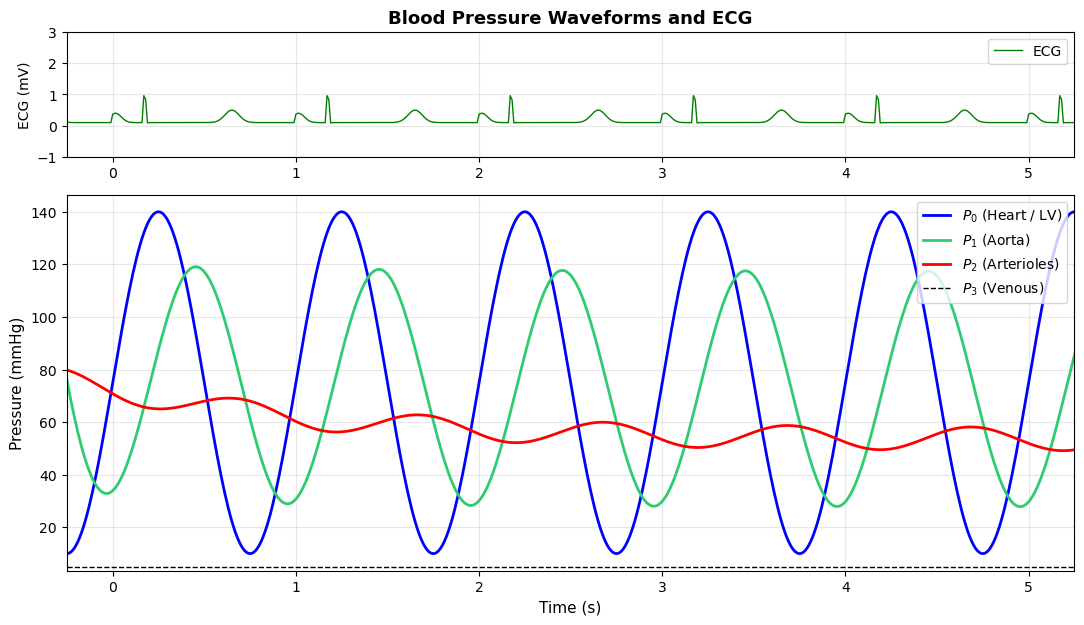

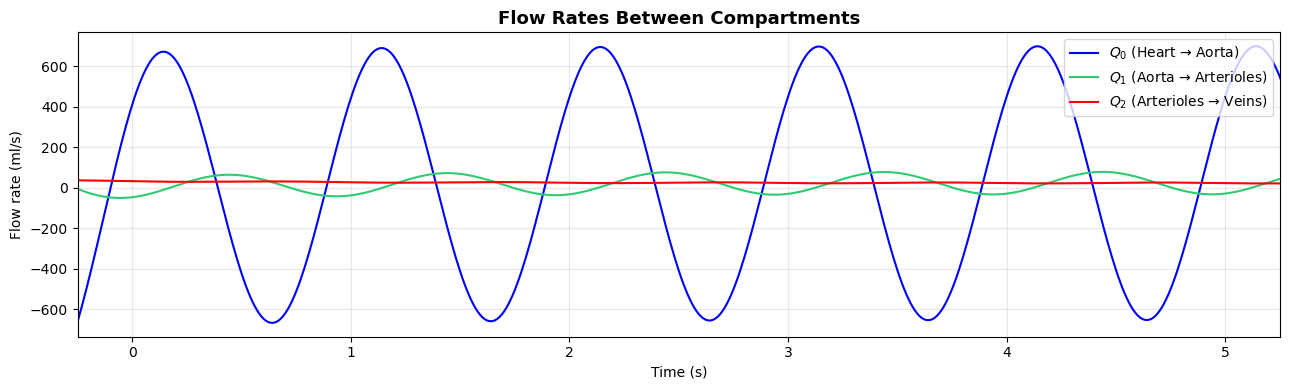

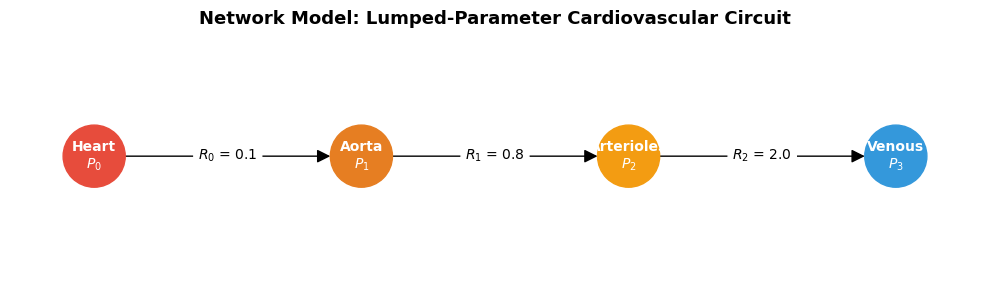

In [13]:
# -- Run the cardiovascular simulation --

# Create model and simulate
model = CardiovascularModel()
time, P0_values, pressures, ecg = model.simulate()

# Create visualizer
viz = FlowVisualizer(model)

# Plot all results
viz.plot_waveforms(time, P0_values, pressures, ecg)
viz.plot_flows(time, P0_values, pressures)
viz.create_network_graph()

### Interpreting the simulation results

**ECG signal (top panel):**
- Shows normal cardiac electrical activity with clear **P waves** (atrial depolarization), **QRS complexes** (ventricular depolarization), and **T waves** (ventricular repolarization)
- Heart rate: 60 bpm (1 beat per second)
- The QRS complex precedes the ventricular pressure rise — reflecting the normal **electro-mechanical coupling delay**

**Pressure waveforms (bottom panel):**

| Signal | Represents | Key features |
|--------|-----------|---------------|
| **P₀ (blue)** | Left ventricular pressure | Oscillates 5–140 mmHg; sharp systolic rise and diastolic fall |
| **P₁ (green)** | Aortic / large artery pressure | Smoothed and delayed version of P₀; compliance C₁ damps the pulsations |
| **P₂ (red)** | Arteriolar pressure | Much less pulsatile; mean ~60 mmHg; further damped by C₂ and R₂ |
| **P₃ (dashed)** | Venous pressure | Constant at 5 mmHg (our simplifying assumption) |

**Flow rates:**
- $Q_0$ (Heart → Aorta) shows the largest pulsatility — driven directly by the heart
- $Q_1$ and $Q_2$ become progressively smoother as compliance and resistance damp the pulsations
- Notice how compliance acts as a **low-pass filter**, converting pulsatile cardiac output into smoother downstream flow

**Network graph:** Shows the four-compartment lumped-parameter model with resistance values connecting the nodes.

### Check Your Understanding: Simulation Results

**Q7.** Why does the $P_1$ (aortic) pressure waveform look "smoother" (less pulsatile) than the $P_0$ (ventricular) pressure waveform?

<details>
<summary>Click to reveal answer</summary>

Two factors contribute:

1. **Compliance $C_1$** at node P₁ acts like a capacitor, storing volume during systole and releasing it during diastole. This smooths out the rapid pressure changes from the heart — like a low-pass filter in electronics.

2. **Resistance $R_0$** between P₀ and P₁ limits how quickly pressure can be transmitted. Combined with C₁, this creates an **RC time constant** ($\tau_{RC} = R_0 \times C_1 = 0.1 \times 1.5 = 0.15$ s) that determines how rapidly P₁ can follow changes in P₀.

In real physiology, this is exactly what the **Windkessel effect** does: the elastic aorta expands during systole to absorb the ejected blood volume, then recoils during diastole to maintain downstream flow.

</details>

---

**Q8.** The model uses forward Euler integration with $\Delta t = 0.01$ s. What could go wrong if you use a much larger time step, say $\Delta t = 0.5$ s?

<details>
<summary>Click to reveal answer</summary>

Forward Euler is an **explicit** integration method and is only **conditionally stable**. The stability criterion requires:

$$\Delta t < 2 \cdot R_{\min} \cdot C_{\min}$$

With $R_0 = 0.1$ and $C_1 = 1.5$, the smallest RC time constant is $0.1 \times 1.5 = 0.15$ s. A time step of 0.5 s would exceed this, causing the solution to **oscillate wildly and diverge** (numerical instability).

Even before instability, large time steps would **miss the fine temporal structure** of the pressure waveforms, leading to inaccurate results. For cardiac simulations with ~1 Hz fundamental frequency and higher harmonics, $\Delta t = 0.01$ s (100 Hz sampling) is a reasonable choice.

</details>

---

**Q9.** In the pressure plot, there is an initial "transient" phase where the pressures are settling. Why does this happen, and roughly how long does it take to reach steady-state oscillation?

<details>
<summary>Click to reveal answer</summary>

The transient occurs because the **initial conditions** ($P_1 = P_2 = 80$ mmHg) don't exactly match the steady-state solution. The model needs a few cardiac cycles for the pressures to converge to their periodic steady state.

The settling time is governed by the **largest RC time constant** in the system:
- $\tau_1 = R_0 \cdot C_1 = 0.15$ s (fast)
- $\tau_2 = R_2 \cdot C_2 = 4.0$ s (slow!)

So $P_2$ takes the longest to settle — approximately $3\tau_2 \approx 12$ s for 95% convergence. In our 5.5 s simulation, $P_2$ is approximately (but not perfectly) at steady state. You can verify this by running a longer simulation.

</details>

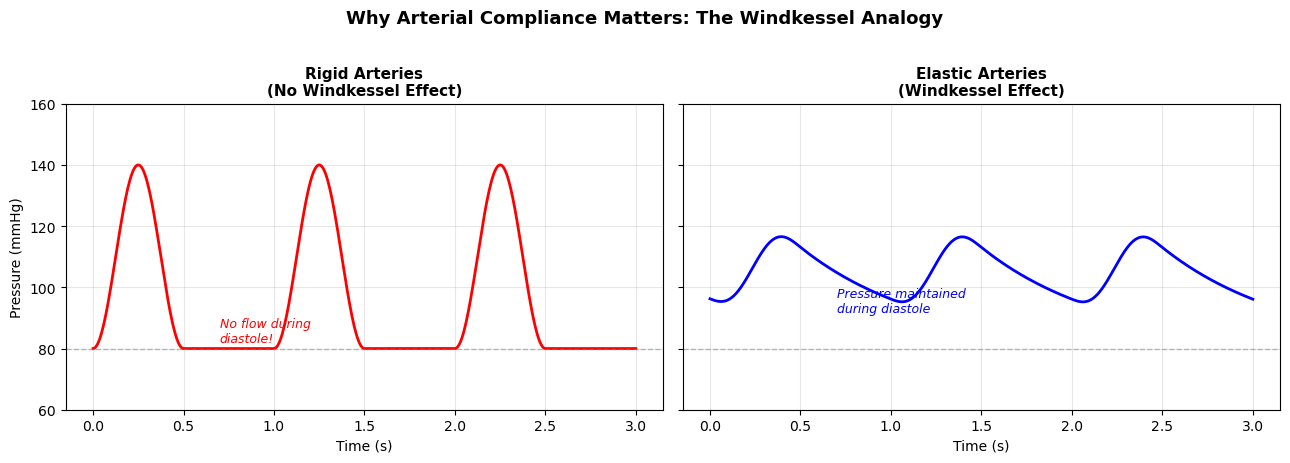

In [14]:
# -- Visualize the Windkessel effect: rigid vs. elastic arteries --

fig, axes = plt.subplots(1, 2, figsize=(13, 4.5), sharey=True)

t_wk = np.linspace(0, 3, 500)  # 3 seconds

# Simulated cardiac output (pulsatile)
Q_heart = np.maximum(0, 400 * np.sin(2 * np.pi * t_wk) ** 2 * (np.sin(2 * np.pi * t_wk) > 0))

# "Rigid" arteries: pressure follows flow directly
P_rigid = 80 + 60 * Q_heart / Q_heart.max()

# "Elastic" arteries: Windkessel ODE smooths the pressure waveform.
# Pre-simulate 10 s so the ODE reaches periodic steady state before the display window.
R_wk, C_wk = 1.0, 0.7
Q_scale = 0.25
dt_wk = t_wk[1] - t_wk[0]
n_settle = int(10.0 / dt_wk)
t_settle = np.linspace(-10, 0, n_settle, endpoint=False)
Q_settle = Q_scale * np.maximum(0, 400 * np.sin(2 * np.pi * t_settle) ** 2
                                     * (np.sin(2 * np.pi * t_settle) > 0))
P_settle = np.zeros(n_settle)
P_settle[0] = 100
for i in range(1, n_settle):
    dP = (Q_settle[i] / C_wk - (P_settle[i-1] - 80) / (R_wk * C_wk)) * dt_wk
    P_settle[i] = P_settle[i-1] + dP
P_elastic = np.zeros_like(t_wk)
P_elastic[0] = P_settle[-1]
Q_display = Q_scale * Q_heart
for i in range(1, len(t_wk)):
    dP = (Q_display[i] / C_wk - (P_elastic[i-1] - 80) / (R_wk * C_wk)) * dt_wk
    P_elastic[i] = P_elastic[i-1] + dP

# Left panel: rigid
axes[0].plot(t_wk, P_rigid, 'r-', lw=2)
axes[0].set_title('Rigid Arteries\n(No Windkessel Effect)', fontsize=11, fontweight='bold')
axes[0].set_xlabel('Time (s)')
axes[0].set_ylabel('Pressure (mmHg)')
axes[0].set_ylim(60, 160)
axes[0].grid(True, alpha=0.3)
axes[0].axhline(80, color='gray', ls='--', lw=1, alpha=0.5)
axes[0].annotate('No flow during\ndiastole!', xy=(0.7, 82), fontsize=9,
                color='red', fontstyle='italic')

# Right panel: elastic (Windkessel)
axes[1].plot(t_wk, P_elastic, 'b-', lw=2)
axes[1].set_title('Elastic Arteries\n(Windkessel Effect)', fontsize=11, fontweight='bold')
axes[1].set_xlabel('Time (s)')
axes[1].set_ylim(60, 160)
axes[1].grid(True, alpha=0.3)
axes[1].axhline(80, color='gray', ls='--', lw=1, alpha=0.5)
axes[1].annotate('Pressure maintained\nduring diastole', xy=(0.7, 92), fontsize=9,
                color='blue', fontstyle='italic')

fig.suptitle('Why Arterial Compliance Matters: The Windkessel Analogy',
             fontsize=13, fontweight='bold', y=1.02)
plt.tight_layout()
plt.show()

### DIY Exercises: Explore the Lumped-Parameter Model

**Exercise 1: Simulate Hypertension — Increased Peripheral Resistance**

In hypertension, arteriolar smooth muscle contraction increases peripheral resistance. Simulate this by increasing $R_2$ from 2.0 to 4.0 mmHg·s/ml.

<details>
<summary>Click for starter code</summary>

Create a new `CardiovascularModel()`, set `model_hyper.R[2] = 4.0`, run `simulate()`, and compare the aortic pressure $P_1$ with the normal case. Focus on the steady-state region (t > 3 s) using `plt.xlim(3, 5.25)`.

</details>

<details>
<summary>Click to reveal what you should see</summary>

With doubled peripheral resistance ($R_2 = 4.0$):
- **Mean aortic pressure increases** significantly — the heart must generate more pressure to push the same flow through higher resistance
- **Diastolic pressure increases** more than systolic — the higher downstream resistance slows pressure decay during diastole
- This is the hemodynamic basis of **systolic and diastolic hypertension**

In real patients, chronic hypertension leads to left ventricular hypertrophy (the heart muscle thickens to handle the increased workload), arterial remodeling, and increased cardiovascular risk.

</details>

---

**Exercise 2: Simulate Aortic Stiffening (Aging / Arteriosclerosis)**

With aging, large arteries lose elasticity (compliance decreases). Simulate this by reducing $C_1$ from 1.5 to 0.3 ml/mmHg.

<details>
<summary>Click for starter code</summary>

Create a new `CardiovascularModel()`, set `model_stiff.C[0] = 0.3`, run `simulate()`, and compare the aortic pressure $P_1$ with the normal case.

</details>

<details>
<summary>Click to reveal what you should see</summary>

With reduced compliance ($C_1 = 0.3$):
- **Systolic pressure increases** dramatically — stiff arteries cannot expand to buffer the ejected volume
- **Diastolic pressure decreases** — without elastic recoil, pressure falls faster between beats
- **Pulse pressure** (systolic − diastolic) **increases** significantly — the hallmark of **isolated systolic hypertension** common in elderly patients
- The waveform becomes "spikier" — resembling the rigid-artery case shown earlier

This is clinically significant: increased **pulse wave velocity** (due to stiffness) is an independent predictor of cardiovascular events.

</details>

---

**Exercise 3: Explore the Effect of Heart Rate**

Change the cardiac period $T$ from 1.0 s (60 bpm) to 0.5 s (120 bpm, as during exercise). What happens to the pressure waveforms?

<details>
<summary>Click for starter code</summary>

Create a new `CardiovascularModel()`, set `model_tachy.T = 0.5`, run `simulate()`, and use a `FlowVisualizer` to plot the waveforms.

</details>

<details>
<summary>Click to reveal what you should see</summary>

At 120 bpm:
- The frequency of oscillations **doubles** (2 beats per second)
- **Diastolic filling time is shorter**, so diastolic pressure may be higher (less time for runoff)
- The pressure waveforms have **less time to decay** between beats
- Mean arterial pressure may change depending on the balance of cardiac output increase and filling time decrease

In real physiology, the heart also adjusts stroke volume and contractility during exercise (via the Frank-Starling mechanism and sympathetic stimulation), which our simple model does not capture — but it illustrates the basic effect of heart rate on hemodynamics.

</details>

In [15]:
# -- DIY: Implement the exercises above --
# Use this cell to experiment with the CardiovascularModel.
# The model and viz objects from earlier cells are available.

# --- Exercise 1: Hypertension ---
# model_hyper = CardiovascularModel()
# model_hyper.R[2] = 4.0
# time_h, P0_h, pressures_h, ecg_h = model_hyper.simulate()
# plt.figure(figsize=(12, 5))
# plt.plot(time, pressures[:, 0], 'b-', lw=2, label='Normal')
# plt.plot(time_h, pressures_h[:, 0], 'r-', lw=2, label='Hypertensive')
# plt.xlabel('Time (s)'); plt.ylabel('Aortic Pressure (mmHg)')
# plt.title('Effect of Increased Peripheral Resistance')
# plt.legend(); plt.grid(True, alpha=0.3); plt.xlim(3, 5.25)
# plt.show()

# --- Exercise 2: Aortic stiffening ---
# model_stiff = CardiovascularModel()
# model_stiff.C[0] = 0.3
# time_s, P0_s, pressures_s, ecg_s = model_stiff.simulate()
# ... plot comparison ...

# --- Exercise 3: Tachycardia ---
# model_tachy = CardiovascularModel()
# model_tachy.T = 0.5
# time_t, P0_t, pressures_t, ecg_t = model_tachy.simulate()
# viz_t = FlowVisualizer(model_tachy)
# viz_t.plot_waveforms(time_t, P0_t, pressures_t, ecg_t)

## 9. Beyond Lumped Parameters: Toward 1D and 3D Models

### 1D Pulse Wave Propagation

The lumped-parameter model cannot capture **spatial** aspects of blood flow — where in the aorta is the pressure highest? How do pulse waves reflect at bifurcations? For this, we need at least a **1D model**.

The 1D equations for flow in an elastic tube (cross-sectionally averaged) are:

$$\frac{\partial A}{\partial t} + \frac{\partial (A u)}{\partial x} = 0 \quad \text{(conservation of mass)}$$

$$\frac{\partial u}{\partial t} + u \frac{\partial u}{\partial x} + \frac{1}{\rho}\frac{\partial p}{\partial x} = -\frac{f}{\rho A} \quad \text{(conservation of momentum)}$$

where $A(x,t)$ is the cross-sectional area, $u(x,t)$ is the velocity, $p(x,t)$ is the pressure, and $f$ represents viscous friction. These are closed by a **tube law** relating pressure to area:

$$p - p_{\text{ext}} = \frac{\beta}{A_0}\left(\sqrt{A} - \sqrt{A_0}\right), \quad \beta = \frac{\sqrt{\pi} \, h \, E}{1 - \nu^2}$$

where $E$ is the Young's modulus of the vessel wall, $h$ is wall thickness, $A_0$ is the reference area, and $\nu$ is the Poisson ratio.

These equations form a **hyperbolic system** that supports wave propagation at the **pulse wave velocity**:

$$c = \sqrt{\frac{\beta}{2\rho A_0}} \cdot A^{1/4}$$

The code cell below demonstrates a simplified 1D pulse wave propagation in a single elastic tube.

### 3D Computational Fluid Dynamics (CFD)

For detailed local flow fields — especially near stenoses, bifurcations, and valves — the full **3D Navier-Stokes equations** are solved, often with:

- **Patient-specific geometry** reconstructed from CT or MRI scans
- **Fluid-structure interaction** (FSI) to model wall deformation
- **Non-Newtonian** blood rheology for accurate shear-dependent viscosity
- **Turbulence models** for high-Reynolds-number flows (e.g., post-stenotic jets)

These simulations typically require high-performance computing and specialized software (e.g., SimVascular, CRIMSON, OpenFOAM, COMSOL).

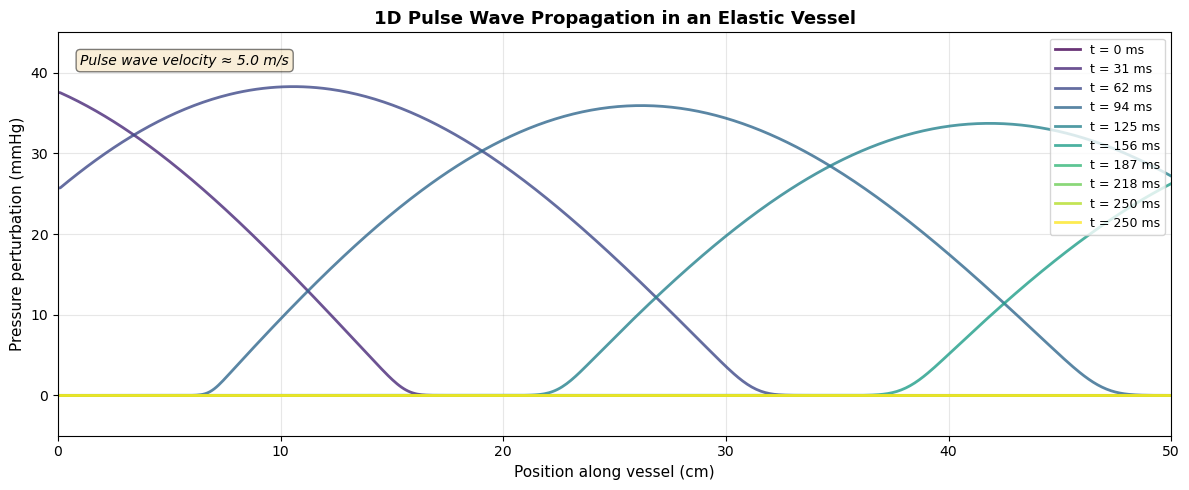

In [16]:
# -- Simple 1D pulse wave propagation demo --
# Demonstrates how a pressure pulse travels along an elastic tube
# using the linearized 1D wave equation: dP/dt + c * dP/dx = -alpha*P
# Solved with a simple upwind (first-order) finite difference scheme.

# Vessel parameters
L = 0.5          # Vessel length (m)
Nx = 500         # Spatial grid points
dx = L / Nx
x_1d = np.linspace(0, L, Nx)

# Physical parameters
c0 = 5.0         # Pulse wave velocity (m/s)
alpha = 2.0      # Viscous damping coefficient (1/s)

# Time parameters
T_total = 0.25   # Total simulation time (s)
CFL = 0.8        # Courant number (must be < 1 for stability)
dt_1d = CFL * dx / c0
Nt = int(T_total / dt_1d)

# Initialize pressure
P_1d = np.zeros(Nx)

# Inlet pressure pulse (half-sine, ~0.08s duration)
def inlet_pulse(t):
    if 0 < t < 0.08:
        return 40.0 * np.sin(np.pi * t / 0.08)  # 40 mmHg pulse
    return 0.0

# Storage for snapshots
snapshots_P = []
snapshot_times = []
snap_interval = max(1, Nt // 8)

# Upwind scheme: forward wave propagation with damping
for n in range(Nt):
    t_1d = n * dt_1d

    # Save snapshots at regular intervals
    if n % snap_interval == 0:
        snapshots_P.append(P_1d.copy())
        snapshot_times.append(t_1d * 1000)  # ms

    # Inlet boundary condition
    P_1d[0] = inlet_pulse(t_1d)

    # Upwind finite difference update (wave moving in +x direction)
    P_new = P_1d.copy()
    for i in range(1, Nx):
        P_new[i] = P_1d[i] - CFL * (P_1d[i] - P_1d[i-1]) - alpha * P_1d[i] * dt_1d

    P_1d = P_new

# Add final snapshot
snapshots_P.append(P_1d.copy())
snapshot_times.append(T_total * 1000)

# Plot snapshots
fig, ax = plt.subplots(figsize=(12, 5))
colors = plt.cm.viridis(np.linspace(0, 1, len(snapshots_P)))

for i, (snap, t_ms) in enumerate(zip(snapshots_P, snapshot_times)):
    ax.plot(x_1d * 100, snap, color=colors[i], lw=2, label=f't = {t_ms:.0f} ms', alpha=0.8)

ax.set_xlabel('Position along vessel (cm)', fontsize=11)
ax.set_ylabel('Pressure perturbation (mmHg)', fontsize=11)
ax.set_title('1D Pulse Wave Propagation in an Elastic Vessel',
             fontsize=13, fontweight='bold')
ax.legend(loc='upper right', fontsize=9)
ax.grid(True, alpha=0.3)
ax.set_xlim(0, L * 100)
ax.set_ylim(-5, 45)
ax.annotate(f'Pulse wave velocity \u2248 {c0} m/s', xy=(0.02, 0.92),
            xycoords='axes fraction', fontsize=10, fontstyle='italic',
            bbox=dict(boxstyle='round', facecolor='wheat', alpha=0.5))
plt.tight_layout()
plt.show()

## 10. Going Deeper

### Extensions of the lumped-parameter model

The basic model presented here can be extended in many directions:

- **More compartments**: Add pulmonary circulation, coronary circulation, cerebral circulation
- **Heart valves**: Model valves as diodes (one-way flow) with opening/closing dynamics
- **Inertance**: Add inductors ($L$) to capture blood inertia effects → 4-element Windkessel
- **Baroreceptor reflex**: Implement a feedback controller that adjusts heart rate and peripheral resistance based on arterial pressure
- **Ventricular pressure-volume loops**: Replace the sinusoidal P₀ with a time-varying elastance model for more realistic ventricular mechanics
- **Pathological conditions**: Simulate aortic regurgitation, mitral stenosis, ventricular septal defect

### Key references

1. **Westerhof, N., Lankhaar, J.-W., & Westerhof, B.E.** (2009). The arterial Windkessel. *Medical & Biological Engineering & Computing*, 47, 131–141. [The modern review of Windkessel models]
2. **Quarteroni, A., Manzoni, A., & Vergara, C.** (2017). The cardiovascular system: Mathematical modelling, numerical algorithms and clinical applications. *Acta Numerica*, 26, 365–590. [Comprehensive review of all modeling levels]
3. **Shi, Y., Lawford, P., & Hose, R.** (2011). Review of zero-D and 1-D models of blood flow in the cardiovascular system. *BioMedical Engineering OnLine*, 10, 33. [Excellent comparison of 0D and 1D approaches]
4. **Taylor, C.A. & Figueroa, C.A.** (2009). Patient-specific modeling of cardiovascular mechanics. *Annual Review of Biomedical Engineering*, 11, 109–134. [Patient-specific CFD]
5. **Nichols, W.W., O'Rourke, M.F., & Vlachopoulos, C.** (2011). *McDonald's Blood Flow in Arteries*. 6th edition. [The classic textbook on arterial hemodynamics]

### Useful resources

- **SimVascular** — Open-source cardiovascular simulation platform: https://simvascular.github.io/
- **OpenBF** — Open-source 1D blood flow solver in Julia: https://github.com/INSIGNEO/openBF
- **Pulse wave hemodynamics** (review article, open access): https://doi.org/10.1152/ajpheart.00218.2021
- **Cardiovascular Mathematics** (Formaggia, Quarteroni, Veneziani) — comprehensive textbook on mathematical modeling of the cardiovascular system